In [1]:
import keystroke_cvae_freetext_realism as kc

In [2]:
kc.set_seed(42)

In [3]:
df, X, C, scaler, encoder, feature_cols, meta_cols, clip_bounds = kc.load_data("free-text.csv")

Rows before cleaning: 562583
Rows after cleaning : 562372
Dropped rows        : 211
Cleaned data shape: (562372, 9)
Feature shape     : (562372, 5)
Condition shape   : (562372, 101)


In [4]:
df_train, df_val, df_test, X_train, X_val, X_test, C_train, C_val, C_test = kc.split_data_by_participant_session(df, X, C)

Train: (393656, 5) (393656, 101)
Val  : (84362, 5) (84362, 101)
Test : (84354, 5) (84354, 101)


In [5]:
train_loader, val_loader = kc.create_loaders(X_train, X_val, C_train, C_val, batch_size=256)

In [6]:
model = kc.build_model(X_train.shape[1], C_train.shape[1], latent_dim=16, dropout=0.03)

In [7]:
model, train_losses, val_losses = kc.train(
    model,
    train_loader,
    val_loader,
    epochs=60,
    lr=0.00025,
    beta_max=0.00005,
    patience=10
)

Epoch 1/60 | Beta 0.000003 | Train 0.048901 | Val 0.008627
Epoch 2/60 | Beta 0.000007 | Train 0.007458 | Val 0.002054
Epoch 3/60 | Beta 0.000010 | Train 0.003389 | Val 0.001321
Epoch 4/60 | Beta 0.000013 | Train 0.002668 | Val 0.000868
Epoch 5/60 | Beta 0.000017 | Train 0.002371 | Val 0.000860
Epoch 6/60 | Beta 0.000020 | Train 0.002146 | Val 0.000963
Epoch 7/60 | Beta 0.000023 | Train 0.002029 | Val 0.000740
Epoch 8/60 | Beta 0.000027 | Train 0.001890 | Val 0.000700
Epoch 9/60 | Beta 0.000030 | Train 0.001786 | Val 0.000505
Epoch 10/60 | Beta 0.000033 | Train 0.001714 | Val 0.000569
Epoch 11/60 | Beta 0.000037 | Train 0.001666 | Val 0.000649
Epoch 12/60 | Beta 0.000040 | Train 0.001598 | Val 0.001213
Epoch 13/60 | Beta 0.000043 | Train 0.001534 | Val 0.001079
Epoch 14/60 | Beta 0.000047 | Train 0.001502 | Val 0.000649
Epoch 15/60 | Beta 0.000050 | Train 0.001469 | Val 0.000500
Epoch 16/60 | Beta 0.000050 | Train 0.001422 | Val 0.000534
Epoch 17/60 | Beta 0.000050 | Train 0.001393 | Va

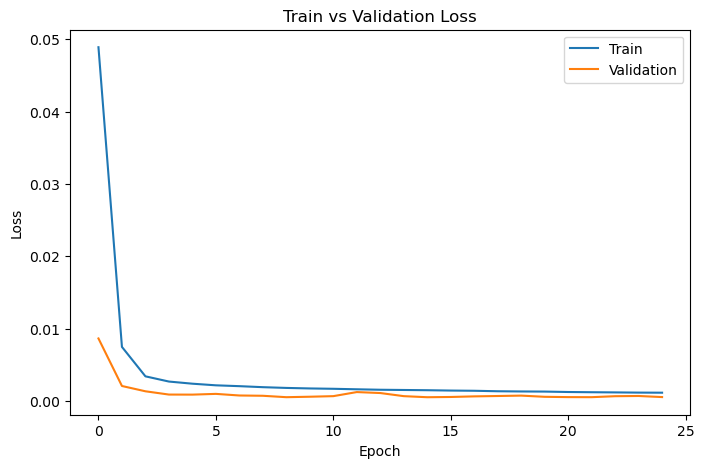

In [8]:
kc.plot_loss(train_losses, val_losses)

In [9]:
synthetic_df = kc.generate_same_shape(
    model,
    df,
    scaler,
    encoder,
    feature_cols,
    meta_cols,
    clip_bounds,
    temperature=1.02,
    quantile_calibration=True
)

Real shape      : (562372, 9)
Synthetic shape : (562372, 9)


In [10]:
kc.save_dataset(synthetic_df, "synthetic_free_text.csv")

Saved dataset to: /Users/shikharraj/Desktop/BB final project/FREE_TEXT/VAE Generator/synthetic_free_text.csv


In [11]:
kc.compare_stats(df, synthetic_df, feature_cols)

REAL MEANS
DU.key1.key1    0.159343
DD.key1.key2    0.271341
DU.key1.key2    0.430275
UD.key1.key2    0.094820
UU.key1.key2    0.254368
dtype: float64

SYNTHETIC MEANS
DU.key1.key1    0.159343
DD.key1.key2    0.271341
DU.key1.key2    0.430275
UD.key1.key2    0.094820
UU.key1.key2    0.254368
dtype: float64

REAL STDS
DU.key1.key1    1.047118
DD.key1.key2    1.662964
DU.key1.key2    1.365906
UD.key1.key2    1.075000
UU.key1.key2    0.299841
dtype: float64

SYNTHETIC STDS
DU.key1.key1    1.047118
DD.key1.key2    1.662964
DU.key1.key2    1.365906
UD.key1.key2    1.075000
UU.key1.key2    0.299841
dtype: float64


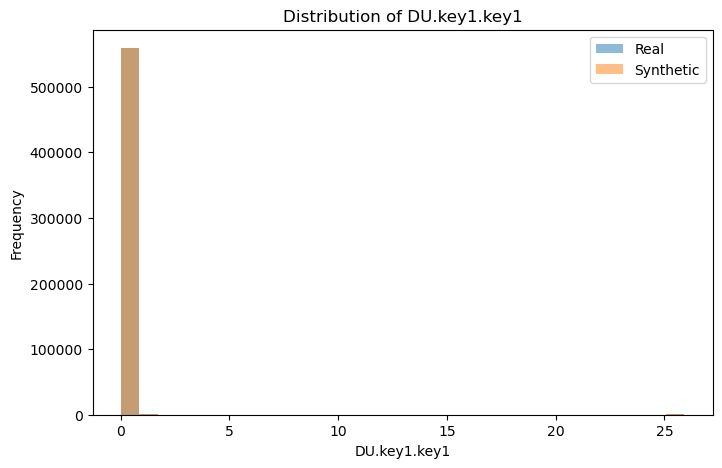

In [12]:
kc.plot_feature_hist(df, synthetic_df, feature_cols[0])

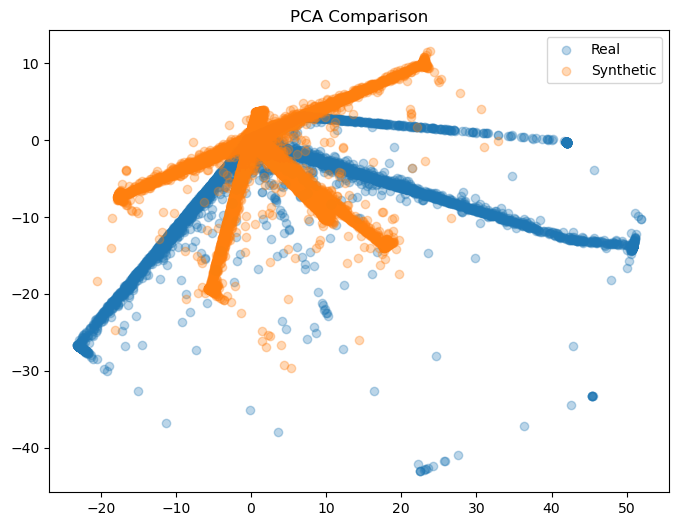

In [13]:
kc.plot_pca(df, synthetic_df, feature_cols)

In [14]:
kc.save_dataset(synthetic_df, "synthetic_free_text.csv")

Saved dataset to: /Users/shikharraj/Desktop/BB final project/FREE_TEXT/VAE Generator/synthetic_free_text.csv
